In [1]:
import pandas as pd
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from patsy import dmatrix
from patsy import build_design_matrices
import shap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import math
import mysql.connector


c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fatigue & Rythm Factors

Player 1 - Fatigue: 0.327, Rhythm: 1.000
Player 2 - Fatigue: 0.041, Rhythm: 0.343


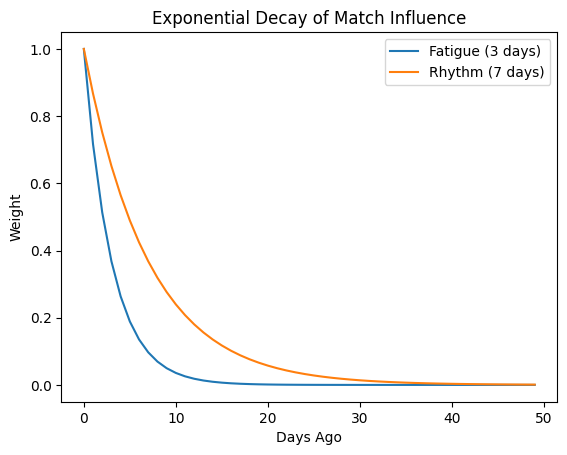

In [2]:
# (minutes played, days ago)
player1_matches = [ 
    (45, 3),   
    (90, 7),   
    (90, 10), 
    (90, 14),  
    (90, 21),  
    (90, 28),  
    (90, 35),  
    (90, 42),  
    (90, 48), 
]

player2_matches = [
    (90, 10),   
    (45, 14),   
    (45, 21),
    (45, 28),  
    (45, 40), 
]

# Fatigue calculation (3-day decay)
player1_total_decayed_minutes_fatigue = sum(minutes * math.exp(-days / 3) for minutes, days in player1_matches)
player1_fatigue = min(1, player1_total_decayed_minutes_fatigue / 90)

player2_total_decayed_minutes_fatigue = sum(minutes * math.exp(-days / 3) for minutes, days in player2_matches)
player2_fatigue = min(1, player2_total_decayed_minutes_fatigue / 90)

# Rhythm calculation (7-day decay)
player1_total_decayed_minutes_rhythm = sum(minutes * math.exp(-days / 7) for minutes, days in player1_matches)
player1_rhythm = min(1, player1_total_decayed_minutes_rhythm / 90)

player2_total_decayed_minutes_rhythm = sum(minutes * math.exp(-days / 7) for minutes, days in player2_matches)
player2_rhythm = min(1, player2_total_decayed_minutes_rhythm / 90)

print(f"Player 1 - Fatigue: {player1_fatigue:.3f}, Rhythm: {player1_rhythm:.3f}")
print(f"Player 2 - Fatigue: {player2_fatigue:.3f}, Rhythm: {player2_rhythm:.3f}")

days = range(0, 50)

fatigue = [math.exp(-d / 3) for d in days]
rhythm_7 = [math.exp(-d / 7) for d in days]

plt.plot(days, fatigue, label="Fatigue (3 days)")
plt.plot(days, rhythm_7, label="Rhythm (7 days)")

plt.xlabel("Days Ago")
plt.ylabel("Weight")
plt.title("Exponential Decay of Match Influence")
plt.legend()
plt.show()

Data gathering

In [3]:
# -------------------------
# DATABASE CONNECTION
# -------------------------
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="venomio",
    database="vsp"
)

# -------------------------
# LOAD DF
# -------------------------
fr_df = pd.read_sql("SELECT * FROM player_fatigue_rhythm", conn)

conn.close()

fr_df.head()

C:\Users\markg\AppData\Local\Temp\ipykernel_21468\1471457757.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fr_df = pd.read_sql("SELECT * FROM player_fatigue_rhythm", conn)


,match_id,player_id,fatigue,rhythm,r_adjustment,f_adjustment
0,13401,Andreas Pereira_18_F,0.097,0.517,-0.000434,-0.001800
1,13401,Antonee Robinson_33_F,0.000,0.000,-0.000434,-0.001703
2,13401,Bernd Leno_17_F,0.116,0.605,-0.000434,0.001438
3,13401,Bobby De Cordova-Reid_14_F,0.024,0.188,-0.000434,0.000182
4,13401,Brenden Aaronson_7_LU,0.150,0.574,-0.000440,0.004651


In [4]:
def predict_fr_coef(mode: str, coef: float, feature: float, model, design_info=None):
    data_dict = {mode: [feature]}
    
    if design_info:
        # Use the training design info to ensure consistent knots for B-splines
        # IMPORTANT: This will raise an error if feature is outside knot range
        # So we clip it just in case, or ensure training covered [0, 1]
        data_dict[mode] = [max(0.0, min(1.0, feature))]
        X = build_design_matrices([design_info], data_dict)[0]
    else:
        # Fallback with explicit bounds
        formula = f"bs({mode}, df=5, degree=3, include_intercept=False, lower_bound=0.0, upper_bound=1.0)"
        X = dmatrix(formula, data_dict, return_type="dataframe")

    adjustment = model.predict(X)[0]
    return coef + adjustment


# Rhytm (Offense)

In [5]:
rhythm_df = fr_df[['rhythm', 'r_adjustment']].copy()
features = ['rhythm']
target = 'r_adjustment'
X = rhythm_df[features]
y = rhythm_df[target]
rhythm_df.head()

,rhythm,r_adjustment
0,0.517,-0.000434
1,0.000,-0.000434
2,0.605,-0.000434
3,0.188,-0.000434
4,0.574,-0.000440


In [6]:
# Force bounds to 0.0 and 1.0 so prediction doesn't fail for boundary values
x_rhythm = dmatrix(
    "bs(rhythm, df=5, degree=3, include_intercept=False, lower_bound=0.0, upper_bound=1.0)",
    data=rhythm_df,
    return_type="dataframe"
)
rhythm_design_info = x_rhythm.design_info

y_rhythm = rhythm_df["r_adjustment"]

rhythm_model = Ridge(alpha=1e-5)
rhythm_model.fit(x_rhythm, y_rhythm)

for rhythm in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    predicted = predict_fr_coef(
        mode="rhythm",
        coef=0.01,
        feature=rhythm,
        model=rhythm_model,
        design_info=rhythm_design_info,
    )
    print(f"Rhythm {rhythm}: {predicted:.6f}")


c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


Rhythm 0.0: 0.009913
Rhythm 0.1: 0.009872
Rhythm 0.2: 0.009865
Rhythm 0.3: 0.009871
Rhythm 0.4: 0.009872
Rhythm 0.5: 0.009862
Rhythm 0.6: 0.009855
Rhythm 0.7: 0.009863
Rhythm 0.8: 0.009878
Rhythm 0.9: 0.009890
Rhythm 1.0: 0.009888


c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid fe

# Fatigue (Defense)

In [7]:
fatigue_df = fr_df[['fatigue', 'f_adjustment']].copy()
features = ['fatigue']
target = 'f_adjustment'
X = fatigue_df[features]
y = fatigue_df[target]
fatigue_df.head()

,fatigue,f_adjustment
0,0.097,-0.001800
1,0.000,-0.001703
2,0.116,0.001438
3,0.024,0.000182
4,0.150,0.004651


In [8]:
# Force bounds to 0.0 and 1.0 so prediction doesn't fail for boundary values
x_fatigue = dmatrix(
    "bs(fatigue, df=5, degree=3, include_intercept=False, lower_bound=0.0, upper_bound=1.0)",
    data=fatigue_df,
    return_type="dataframe"
)
fatigue_design_info = x_fatigue.design_info

y_fatigue = fatigue_df["f_adjustment"]

# Alpha lowered to 1e-5
fatigue_model = Ridge(alpha=1e-5)
fatigue_model.fit(x_fatigue, y_fatigue)

for fatigue in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    predicted = predict_fr_coef(
        mode="fatigue",
        coef=0.01,
        feature=fatigue,
        model=fatigue_model,
        design_info=fatigue_design_info,
    )
    print(f"Fatigue {fatigue}: {predicted:.6f}")


Fatigue 0.0: 0.009617
Fatigue 0.1: 0.009542
Fatigue 0.2: 0.009371
Fatigue 0.3: 0.009305
Fatigue 0.4: 0.009328
Fatigue 0.5: 0.009407
Fatigue 0.6: 0.009508
Fatigue 0.7: 0.009600
Fatigue 0.8: 0.009648
Fatigue 0.9: 0.009622
Fatigue 1.0: 0.009487


c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
c:\Users\markg\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid fe